In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [ ]:
df = pd.read_csv(
    r"C:/Users/pushp/Desktop/simple-linear-regession-project-main/simple-linear-regession-project-main/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# data exploration

In [67]:
# checking the data type and null value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [68]:
# Get summary satistics
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


In [69]:
# checking Missing(Null) values
df.isna().sum().sum()

np.int64(0)

In [70]:
# checking duplicate values
df.duplicated().value_counts()

False    1337
True        1
Name: count, dtype: int64

In [ ]:

df.drop_duplicates(inplace = True)

In [72]:
df.duplicated().sum()

np.int64(0)

In [73]:
df_cleaned = df.dropna() 

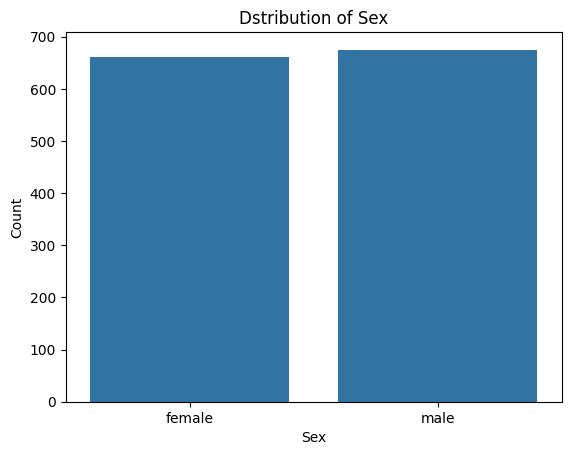

In [74]:
sns.countplot(x = 'sex' , data = df_cleaned)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Dstribution of Sex')
plt.show()

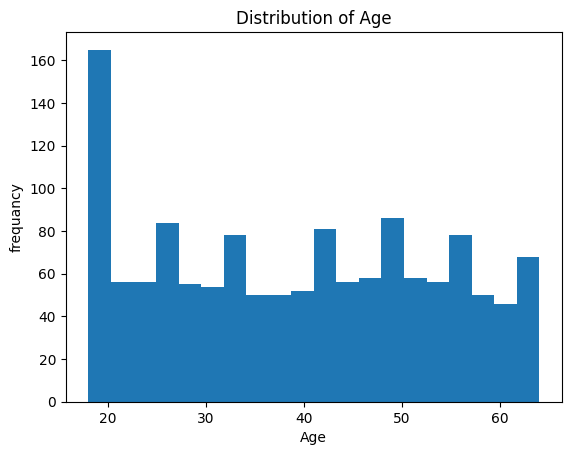

In [75]:
df_cleaned['age'].plot(kind = 'hist' , bins = 20)
plt.xlabel('Age')
plt.ylabel('frequancy')
plt.title('Distribution of Age')
plt.show()

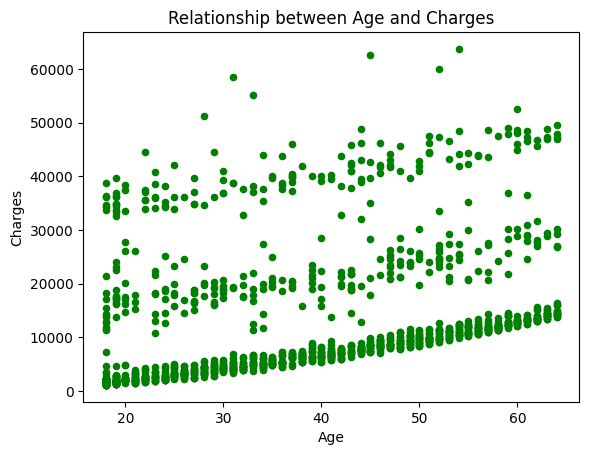

In [76]:
# relationship between age and charges using scatterplot
df_cleaned.plot(kind='scatter', x='age', y='charges', color='g')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.title('Relationship between Age and Charges')
plt.show()


There is a linearly increasing relationship between age and insurance charges. Older people are tend to be charged more

# data preprocessing

#### manipulate categorical coluns

In [77]:
df_encoded = pd.get_dummies(df_cleaned , columns = ['region'] , prefix = 'region' , dtype = 'int')
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
665,43,male,38.060,2,yes,42560.43040,0,0,1,0
646,39,male,26.220,1,no,6123.56880,0,1,0,0
948,42,male,31.255,0,no,6358.77645,0,1,0,0
67,40,male,26.315,1,no,6389.37785,0,1,0,0
1090,47,male,36.190,0,yes,41676.08110,0,0,1,0


In [78]:
labelencoder = LabelEncoder()
df_encoded['smoker_encoded'] = labelencoder.fit_transform(df_encoded['smoker'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
756,39,female,22.800,3,no,7985.81500,1,0,0,0,0
1122,53,female,36.860,3,yes,46661.44240,0,1,0,0,1
1088,52,male,47.740,1,no,9748.91060,0,0,1,0,0
457,57,female,30.495,0,no,11840.77505,0,1,0,0,0
1263,43,female,29.900,1,no,7337.74800,0,0,0,1,0


In [79]:
df_encoded['Sex_encoded'] = labelencoder.fit_transform(df_encoded['sex'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,Sex_encoded
1027,23,male,18.715,0,no,21595.38229,0,1,0,0,0,1
848,27,female,24.100,0,no,2974.12600,0,0,0,1,0,0
909,32,female,24.600,0,yes,17496.30600,0,0,0,1,1,0
168,19,female,31.825,1,no,2719.27975,0,1,0,0,0,0
671,29,female,31.160,0,no,3943.59540,1,0,0,0,0,0


In [80]:
df_encoded = df_encoded[[x for x in df_encoded.columns if x not in ['smoker', 'sex']]]
df_encoded.sample(5)

,age,bmi,children,charges,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,Sex_encoded
1223,20,24.420,0,26125.67477,0,0,1,0,1,0
491,61,25.080,0,24513.09126,0,0,1,0,0,0
32,19,28.600,5,4687.79700,0,0,0,1,0,0
1148,55,21.500,1,10791.96000,0,0,0,1,0,1
765,57,31.825,0,11842.62375,0,1,0,0,0,0


#### checking outlier and remove it

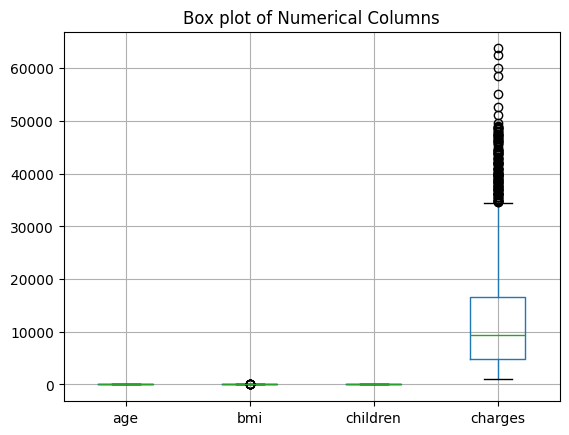

In [81]:
# checking outlier by using box plot for numerical columns
df.boxplot(column=['age', 'bmi', 'children', 'charges']) 
plt.title('Box plot of Numerical Columns')
plt.show()

In [82]:
# Handling  Outlier
# Remove Outlier based on specific threshold
df_cleaned = df[ (df['charges'] < 21000 ) & (df['bmi'] < 46) ]

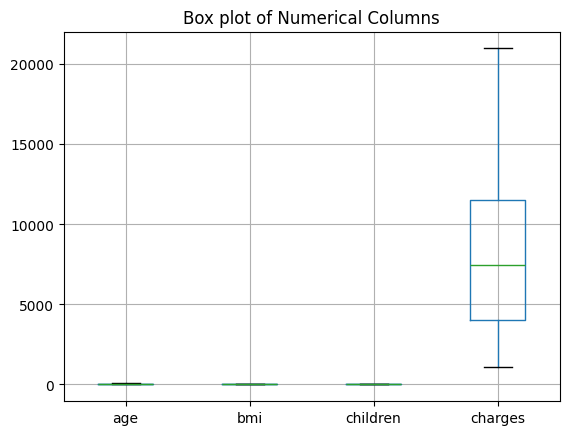

In [83]:
# visualize boxplot after removing outliers
df_cleaned.boxplot(column=['age', 'bmi', 'children', 'charges'])
plt.title('Box plot of Numerical Columns')
plt.show()

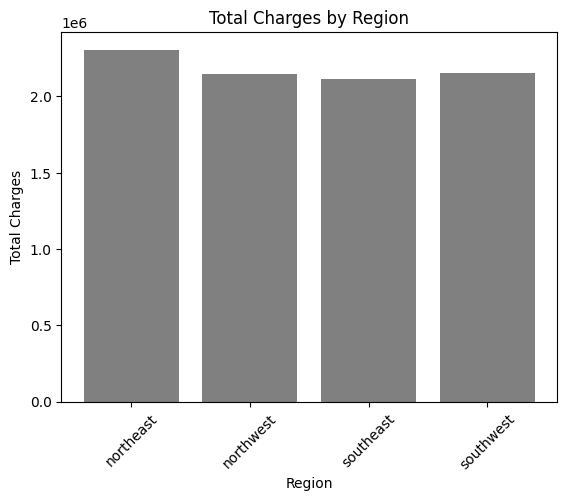

In [84]:
# Calculate the total charges by region
charges_by_region = df_cleaned.groupby('region')['charges'].sum()

# Create a bar chart
plt.bar(charges_by_region.index, charges_by_region.values, color='grey')

# Add labels and title
plt.xlabel('Region')

plt.ylabel('Total Charges')
plt.title('Total Charges by Region')

# Rotate x-axis labels for better visibility (optional)
plt.xticks(rotation=45)

# Display the chart
plt.show()

# Modeling

In [85]:
x = df_encoded.drop(['charges'] , axis = 1)
y = df_encoded['charges']

In [86]:
def predicted_value(q , w):
    x_train , x_test , y_train , y_test = train_test_split(q , w , test_size = 0.2 , random_state = 42
                                                        , shuffle = True)
    lr_model = LinearRegression() 
    lr_model.fit(x_train , y_train)
    y_pred = lr_model.predict(x_test)
    a =  mean_absolute_error(y_test , y_pred)
    b =  mean_squared_error(y_test , y_pred)
    c =  np.sqrt(mean_squared_error(y_test , y_pred))
    return y_pred , a ,  b, c
    
q = x
w = y
predicted_value(q , w) 

(array([ 8.14369388e+03,  5.73711568e+03,  1.43693149e+04,  3.17455136e+04,
         8.96238666e+03,  1.31497224e+04,  3.04467607e+04,  1.45328881e+03,
         1.06330184e+04,  1.13189438e+04,  1.03778536e+04,  3.31184377e+04,
         3.10772527e+04,  1.74119253e+04,  1.08016743e+04,  9.52889964e+03,
         4.16103784e+03,  3.17315373e+04,  3.21938875e+03,  5.22992460e+03,
         3.54979004e+03,  3.02837740e+04,  1.48989509e+04,  3.04569093e+04,
         3.11077668e+04,  5.51196081e+03,  3.55030401e+04,  3.65704810e+04,
         1.14123133e+04,  1.42056990e+04,  6.50234029e+03,  1.27246945e+04,
         3.99806590e+02,  1.20883980e+04,  3.96592069e+04,  1.23395540e+04,
         4.74412279e+03,  3.91903157e+03,  3.08606789e+04,  8.95870663e+03,
         7.05389441e+03,  3.01125636e+04,  3.47804324e+04,  1.22916189e+04,
         7.35739310e+03,  3.42060530e+03,  6.21243471e+03,  8.98345200e+03,
         4.26401828e+03,  9.01992870e+03,  6.60149578e+03,  1.20802337e+04,
         3.1